<a href="https://colab.research.google.com/github/Skylar3017/UCV_ATE_SI_LAB013/blob/develop/Redes_Neuronales_Convolucionales_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
%pip install ucimlrepo tensorflow pandas numpy matplotlib scikit-learn -q

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [13]:
digits = fetch_ucirepo(id=80)

X = digits.data.features
y = digits.data.targets.squeeze()

print('Dimensión de X:', X.shape)
print('Dimensión de y:', y.shape)

X.head()

Dimensión de X: (5620, 64)
Dimensión de y: (5620,)


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute55,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60,Attribute61,Attribute62,Attribute63,Attribute64
0,0,1,6,15,12,1,0,0,0,7,...,0,0,0,0,6,14,7,1,0,0
1,0,0,10,16,6,0,0,0,0,7,...,3,0,0,0,10,16,15,3,0,0
2,0,0,8,15,16,13,0,0,0,1,...,0,0,0,0,9,14,0,0,0,0
3,0,0,0,3,11,16,0,0,0,0,...,0,0,0,0,0,1,15,2,0,0
4,0,0,5,14,4,0,0,0,0,0,...,12,0,0,0,4,12,14,7,0,0


In [14]:
print('Clases disponibles:', sorted(y.unique()))
print('\nDistribución de clases:')
print(y.value_counts().sort_index())

Clases disponibles: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Distribución de clases:
class
0    554
1    571
2    557
3    572
4    568
5    558
6    558
7    566
8    554
9    562
Name: count, dtype: int64


In [15]:
X_images = X.to_numpy().reshape(-1, 8, 8, 1)
y_values = y.to_numpy().astype('int')

print('Nueva forma de X:', X_images.shape)
print('Forma de y:', y_values.shape)

Nueva forma de X: (5620, 8, 8, 1)
Forma de y: (5620,)


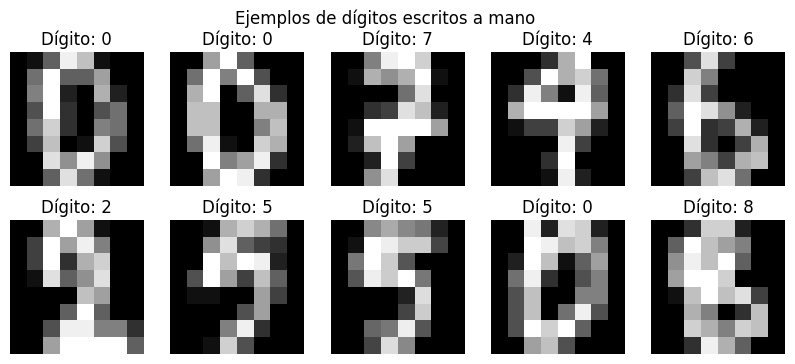

In [16]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_images[i].reshape(8, 8), cmap='gray')
    plt.title(f'Dígito: {y_values[i]}')
    plt.axis('off')

plt.suptitle('Ejemplos de dígitos escritos a mano')
plt.show()

In [17]:
X_images = X_images / 16.0

print('Valor mínimo:', X_images.min())
print('Valor máximo:', X_images.max())

Valor mínimo: 0.0
Valor máximo: 1.0


In [18]:
num_classes = 10
y_categorical = to_categorical(y_values, num_classes=num_classes)

print('Ejemplo etiqueta original:', y_values[0])
print('Ejemplo etiqueta one-hot:', y_categorical[0])

Ejemplo etiqueta original: 0
Ejemplo etiqueta one-hot: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [19]:
X_train, X_test, y_train, y_test, y_train_labels, y_test_labels = train_test_split(
    X_images,
    y_categorical,
    y_values,
    test_size=0.30,
    random_state=42,
    stratify=y_values,
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (3934, 8, 8, 1)
X_test: (1686, 8, 8, 1)
y_train: (3934, 10)
y_test: (1686, 10)


In [20]:
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(8, 8, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (2, 2), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 6, 6, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 2, 2, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,146 (43.54 KB)

 Trainable params: 11,146 (43.54 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4303 - loss: 1.9413 - val_accuracy: 0.6328 - val_loss: 1.1979
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7893 - loss: 0.7670 - val_accuracy: 0.8983 - val_loss: 0.4148
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8834 - loss: 0.4180 - val_accuracy: 0.9352 - val_loss: 0.2590
Epoch 4/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9164 - loss: 0.3039 - val_accuracy: 0.9530 - val_loss: 0.1952
Epoch 5/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9320 - loss: 0.2445 - val_accuracy: 0.9619 - val_loss: 0.1600
Epoch 6/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9377 - loss: 0.2049 - val_accuracy: 0.9670 - val_loss: 0.1407
Epoch 7/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9504 - loss: 0.1767 - val_accuracy: 0.9720 - val_loss: 0.1242
Epoch 8/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9501 - loss: 0.1658 - val_accuracy: 0.9733 - val

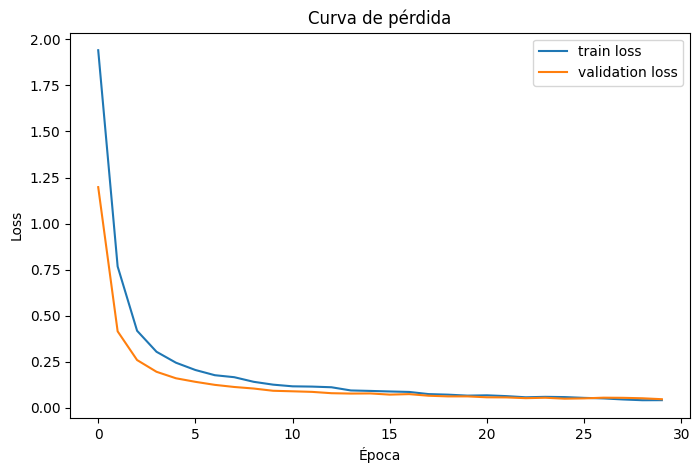

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de pérdida')
plt.legend()
plt.show()

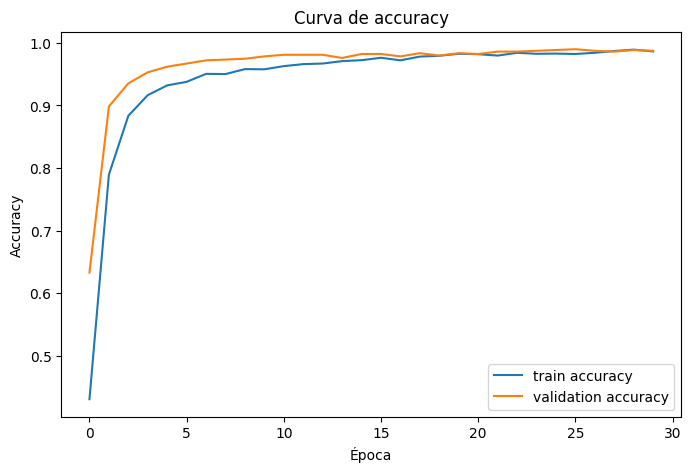

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Curva de accuracy')
plt.legend()
plt.show()

In [24]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f'Test loss    : {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

Test loss    : 0.0487
Test accuracy: 0.9881


In [25]:
y_pred_prob = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test_labels, y_pred_labels))

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       166
           1       0.99      1.00      1.00       171
           2       1.00      0.99      0.99       167
           3       0.98      0.98      0.98       172
           4       0.98      1.00      0.99       171
           5       0.98      0.97      0.98       167
           6       0.99      0.99      0.99       167
           7       0.98      0.99      0.99       170
           8       0.99      0.98      0.99       166
           9       0.98      0.98      0.98       169

    accuracy                           0.99      1686
   macro avg       0.99      0.99      0.99      1686
weighted avg       0.99      0.99      0.99      1686



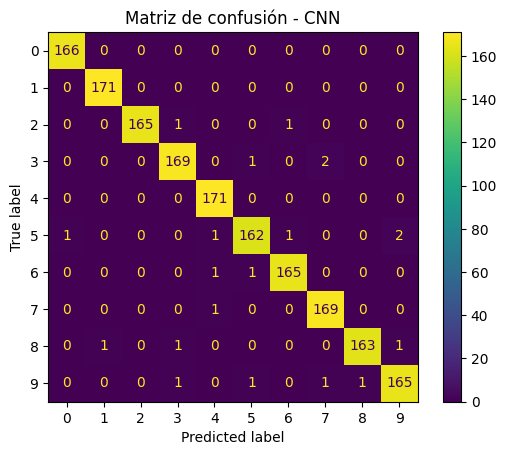

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_test_labels,
    y_pred_labels,
    display_labels=list(range(10)),
)
plt.title('Matriz de confusión - CNN')
plt.show()

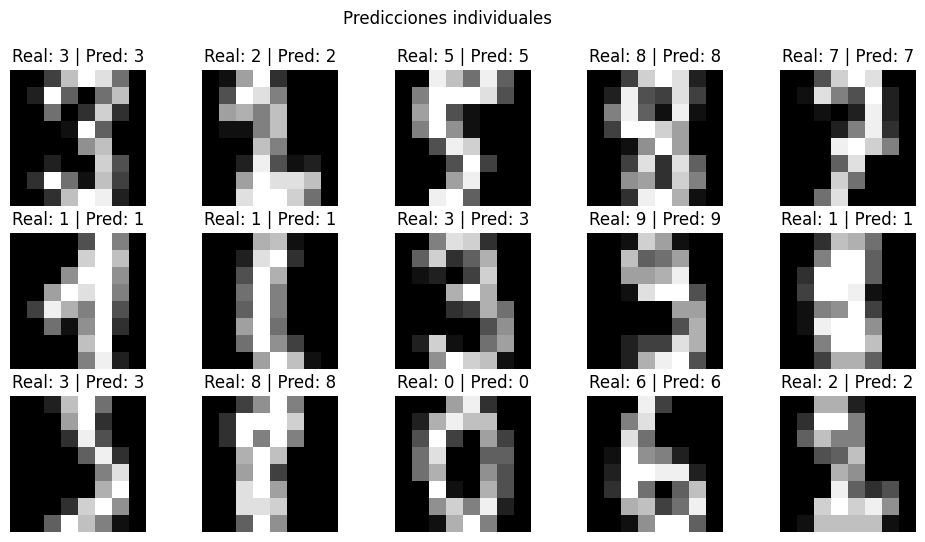

In [27]:
plt.figure(figsize=(12, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i].reshape(8, 8), cmap='gray')
    plt.title(f'Real: {y_test_labels[i]} | Pred: {y_pred_labels[i]}')
    plt.axis('off')

plt.suptitle('Predicciones individuales')
plt.show()

Cantidad de errores: 20


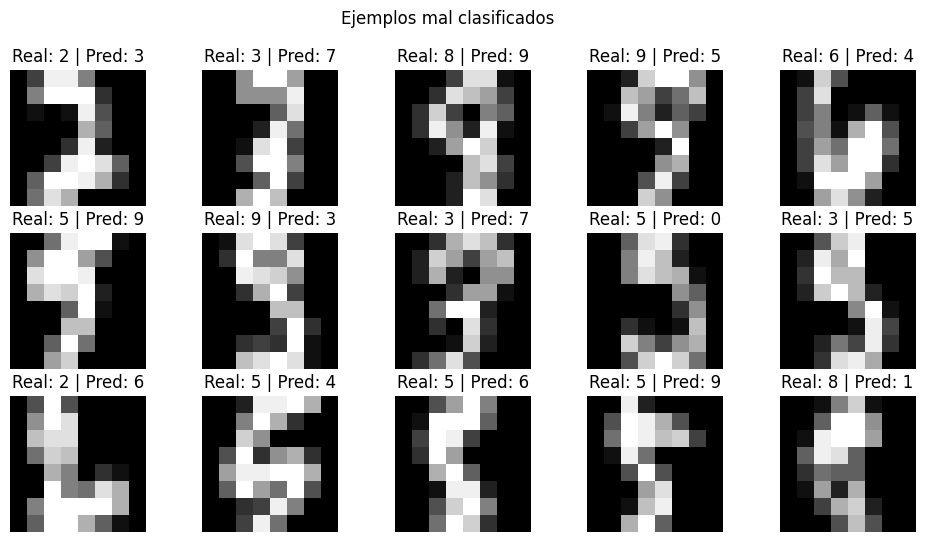

In [28]:
wrong_indices = np.where(y_test_labels != y_pred_labels)[0]

print('Cantidad de errores:', len(wrong_indices))

plt.figure(figsize=(12, 6))

for plot_index, data_index in enumerate(wrong_indices[:15]):
    plt.subplot(3, 5, plot_index + 1)
    plt.imshow(X_test[data_index].reshape(8, 8), cmap='gray')
    plt.title(f'Real: {y_test_labels[data_index]} | Pred: {y_pred_labels[data_index]}')
    plt.axis('off')

plt.suptitle('Ejemplos mal clasificados')
plt.show()

In [29]:
dense_model = Sequential([
    Flatten(input_shape=(8, 8, 1)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

dense_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

dense_history = dense_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

dense_loss, dense_accuracy = dense_model.evaluate(X_test, y_test, verbose=0)

print(f'Accuracy CNN        : {test_accuracy:.4f}')
print(f'Accuracy Dense Model: {dense_accuracy:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Accuracy CNN        : 0.9881
Accuracy Dense Model: 0.9739


In [30]:
model.save('cnn_digits_uci.keras')
print('Modelo guardado como cnn_digits_uci.keras')

Modelo guardado como cnn_digits_uci.keras


# **Resolución de las preguntas de análisis**

### 1. ¿Qué diferencia existe entre una red densa y una CNN?
Una red densa conecta todas las neuronas entre sí, mientras que una CNN está diseñada para trabajar con imágenes mediante filtros que detectan patrones visuales de forma más eficiente.

### 2. ¿Qué función cumple una capa convolucional?
La capa convolucional extrae características importantes de la imagen, como bordes, formas y patrones que ayudan a identificar el objeto representado.

### 3. ¿Qué representa un filtro en una CNN?
Un filtro es una pequeña matriz que recorre la imagen para detectar determinadas características visuales, como líneas, curvas o contornos.

### 4. ¿Qué función cumple MaxPooling?
MaxPooling reduce el tamaño de las imágenes conservando las características más relevantes. Esto disminuye el costo computacional y ayuda a evitar el sobreajuste.

### 5. ¿Por qué normalizamos los valores de píxeles?
Porque los valores originales van de 0 a 255. Al normalizarlos entre 0 y 1 se facilita el entrenamiento y se mejora la estabilidad del modelo.

### 6. ¿Por qué usamos softmax en la capa de salida?
Porque convierte las salidas de la red en probabilidades para cada clase, permitiendo identificar cuál es el dígito más probable.

### 7. ¿Qué dígitos se confundieron más en la matriz de confusión?
Los dígitos que más se confundieron fueron aquellos con formas visualmente parecidas. Esto puede variar según los resultados obtenidos en la matriz de confusión.

### 8. ¿Por qué algunos dígitos escritos a mano son difíciles de clasificar?
Porque las personas escriben los números de formas diferentes, lo que genera variaciones que pueden dificultar la identificación correcta por parte del modelo.

### 9. ¿Qué ventajas tendría usar imágenes de mayor resolución?
Permitirían capturar más detalles y características visuales, lo que podría mejorar la precisión de la clasificación.

### 10. ¿Qué limitaciones tiene este laboratorio frente a un sistema OCR real?
Este laboratorio solo reconoce dígitos individuales en un conjunto de datos controlado. Un sistema OCR real debe reconocer textos completos, diferentes fuentes, tamaños, idiomas y condiciones de iluminación.